### Mengimpor seluruh library yang dibutuhkan untuk pemrosesan citra, ekstraksi fitur, klasifikasi, dan evaluasi model
Pada code terdapat:

- cv2 untuk membaca dan memproses citra<br>
- matplotlib.pyplot untuk visualisasi<br>
- numpy dan pandas untuk manipulasi array dan tabel data<br>
- sklearn untuk klasifikasi (Random Forest, SVM, KNN), pembagian data, dan evaluasi model<br>
- skimage.feature untuk ekstraksi fitur GLCM<br>
- scipy.stats untuk perhitungan entropi<br>
- seaborn untuk visualisasi heatmap<br>
- itertools.combinations untuk membandingkan pasangan file gambar

In [ ]:
# Import library yang kalian butuhkan
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns
from itertools import combinations

### Melakukan pengecekan duplikasi citra dalam dataset dengan membandingkan selisih rata-rata piksel antar pasangan gambar
Pada code terdapat:

- os.listdir untuk membaca semua nama file dalam folder dataset<br>
- Setiap gambar dibaca dalam mode grayscale menggunakan cv.IMREAD_GRAYSCALE dan di-resize ke 64×64 untuk efisiensi perbandingan<br>
- combinations(files, 2) untuk menghasilkan semua pasangan unik file tanpa pengulangan<br>
- np.mean(np.abs(...)) untuk menghitung selisih rata-rata piksel antara dua gambar<br>
- Jika selisih kurang dari THRESHOLD = 5.0, pasangan tersebut dianggap mirip dan dicetak sebagai peringatan duplikasi

In [ ]:

folder = "dataset/Grape_black_rot_100"
files = sorted(os.listdir(folder))

thumbs = {}
for fname in files:
    img = cv.imread(os.path.join(folder, fname), cv.IMREAD_GRAYSCALE)
    thumbs[fname] = cv.resize(img, (64, 64)).astype(np.float32)

THRESHOLD = 5.0  # makin kecil, makin ketat syarat "dianggap mirip"

for f1, f2 in combinations(files, 2):
    diff = np.mean(np.abs(thumbs[f1] - thumbs[f2]))
    if diff < THRESHOLD:
        print(f"MIRIP (selisih={diff:.2f}):", f1, "<->", f2)

### Membaca seluruh data citra dari folder dataset beserta label kelasnya
Pada code terdapat:

- os.listdir("dataset") untuk mendapatkan daftar subfolder yang masing-masing merepresentasikan satu kelas
- cv.imread untuk membaca setiap file gambar; gambar yang gagal dibaca dilewati menggunakan continue
- Setiap gambar disimpan ke list data, label kelasnya ke list labels, dan nama filenya ke list file_name
- print untuk menampilkan total data yang berhasil dibaca dan daftar kelas yang ditemukan

In [140]:
data = []
labels = []
file_name = []

for sub_folder in os.listdir("dataset"):
    sub_folder_files = os.listdir(os.path.join("dataset", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("dataset", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 200
Kelas: ['Grape_black_rot_100', 'daun_sehat_100']


### Mendefinisikan struktur augmentasi data sebagai placeholder yang belum diisi dengan transformasi apapun
Pada code terdapat:

- Tiga list kosong data_augmented, labels_augmented, dan file_name_augmented sebagai wadah hasil augmentasi
- Perulangan for i in range(len(data)) dengan isi pass sebagai kerangka yang belum mengimplementasikan transformasi apapun
- print untuk menampilkan jumlah data sebelum dan sesudah augmentasi sebagai verifikasi

In [141]:
data_augmented = []
labels_augmented = []
paths_augmented = []
file_name_augmented = []
for i in range(len(data)):
	pass
print("Data sebelum augmentasi: ", len(data))
print("Data setelah augmentasi: ", len(data_augmented))

Data sebelum augmentasi:  200
Data setelah augmentasi:  0


### Mendefinisikan fungsi preprocessing untuk mengonversi citra ke grayscale dan menerapkan median filter
Pada code terdapat:

- Fungsi gray yang menerima citra dan ukuran target, melakukan resize ke 256×256, lalu mengonversi ke grayscale menggunakan cv.COLOR_BGR2GRAY jika citra masih berwarna; hasilnya dikembalikan sebagai uint8
- Fungsi median yang menerima citra atau path file, membaca gambar jika input berupa string, lalu menerapkan cv.medianBlur dengan kernel size 5 untuk mengurangi noise
- Fungsi prepro yang menggabungkan kedua fungsi di atas secara berurutan: grayscale dulu kemudian median filter
- Fungsi percobaan1 sebagai wrapper dari prepro yang akan digunakan pada pipeline pemrosesan



In [142]:
TARGET_SIZE = (256, 256)

def gray(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)
    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized
    return gray.astype(np.uint8)

def median(image_input, kernel_size=5):
    if isinstance(image_input, str):
        img = cv.imread(image_input)
    else:
        img = image_input.copy()

    median_hasil = cv.medianBlur(img, kernel_size)
    return median_hasil

### Preprocessing

In [143]:
def prepro(image):
    img = gray(image)
    img = median(img)

    return img

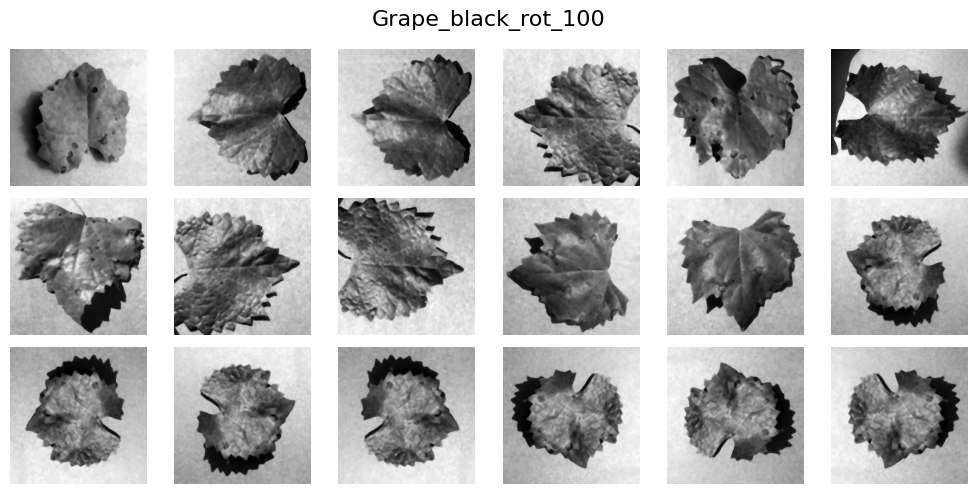

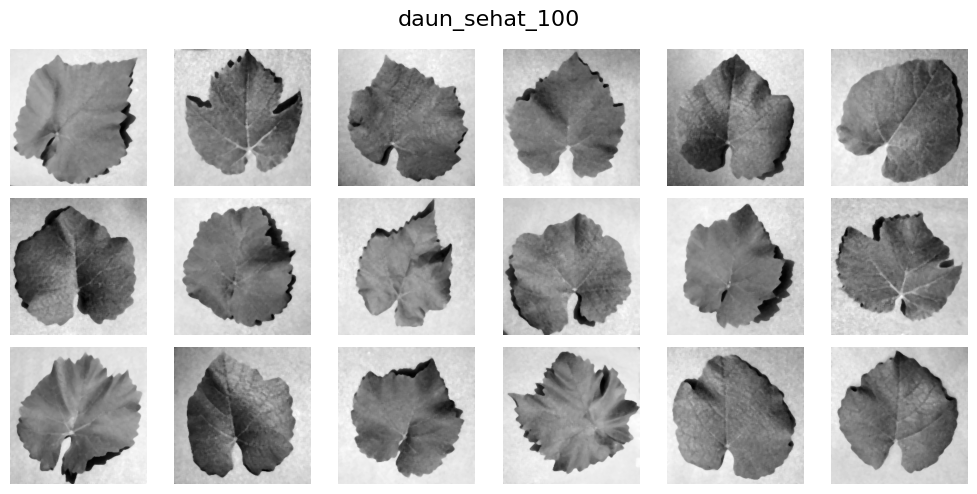

In [144]:
def percobaan1(img):
    hasil = prepro(img)
    return hasil

dataPreprocessed = [percobaan1(img) for img in data]

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]

    fig, axs = plt.subplots(3, 6, figsize=(10, 5))
    fig.suptitle(f'{label}', fontsize=16)

    for k in range(min(18, len(idxs))):
        row = k // 6
        col = k % 6
        ax  = axs[row][col]

        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

### Menerapkan preprocessing pada seluruh data dan menampilkan 18 sampel pertama untuk setiap kelas dalam grid 3×6
Pada code terdapat:

- List comprehension [percobaan1(img) for img in data] untuk menerapkan fungsi preprocessing ke semua gambar sekaligus
- Perulangan per label untuk mengelompokkan indeks gambar berdasarkan kelasnya menggunakan list comprehension [j for j, l in enumerate(labels) if l == label]
- plt.subplots(3, 6) untuk membuat grid tampilan 3 baris dan 6 kolom menampilkan maksimal 18 sampel per kelas
- ax.axis('off') untuk menyembunyikan sumbu agar tampilan lebih bersih

### Feature Extraction

In [145]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")
    
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [146]:
def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Menghitung matriks GLCM untuk setiap citra pada keempat sudut (0°, 45°, 90°, 135°) dan mengekstrak semua fitur tekstur
Pada code terdapat:

Perulangan pertama untuk menghitung matriks GLCM pada empat sudut untuk setiap citra dan menyimpannya ke list Derajat0, Derajat45, Derajat90, Derajat135
Tujuh perulangan terpisah untuk mengekstrak fitur correlation, contrast, dissimilarity, homogeneity, entropy, ASM, dan energy dari setiap matriks GLCM di empat sudut
Setiap nilai fitur disimpan ke list yang sesuai (misalnya Kontras0, correlation45, entropy90) untuk digunakan pada tahap pembuatan tabel



In [147]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

In [148]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []


In [149]:
for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

In [150]:
for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

In [151]:
for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

In [152]:
for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

In [153]:
for i in range(len(data)):  
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

In [154]:
for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

In [155]:
for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

### Menyusun semua fitur hasil ekstraksi ke dalam DataFrame lalu menyimpannya ke file CSV dan menampilkan hasilnya
Pada code terdapat:

- Dictionary dataTable yang menggabungkan nama file, label, dan 28 kolom fitur (7 fitur × 4 sudut) ke dalam satu struktur tabel
- pd.DataFrame(dataTable) untuk mengonversi dictionary menjadi DataFrame pandas
- df.to_csv untuk menyimpan DataFrame ke file hasil_ekstraksi1.csv di folder ekstraksi
- pd.read_csv untuk membaca kembali file CSV yang disimpan dan menampilkannya sebagai verifikasi hasil ekstraksi

In [156]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('./ekstraksi/hasil_ekstraksi1.csv', index=False)

hasilEkstrak = pd.read_csv('./ekstraksi/hasil_ekstraksi1.csv')
hasilEkstrak


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,daun_sehat_100_1.jpg,daun_sehat_100,29.397074,52.360707,23.538909,38.817332,0.585496,0.497931,0.598071,0.505807,...,0.004500,0.003279,0.066603,0.056624,0.067080,0.057260,0.987045,0.976902,0.989634,0.982876
1,daun_sehat_100_2.jpg,daun_sehat_100,41.781771,68.430250,36.362331,65.325536,0.441705,0.356804,0.466834,0.362053,...,0.002242,0.001460,0.044672,0.037543,0.047353,0.038216,0.986650,0.978154,0.988386,0.979146
2,daun_sehat_100_3.jpg,daun_sehat_100,28.830699,50.334241,27.468490,44.424621,0.490187,0.384575,0.478488,0.386837,...,0.001571,0.001088,0.040621,0.032959,0.039642,0.032989,0.989263,0.981236,0.989750,0.983439
3,daun_sehat_100_4.jpg,daun_sehat_100,19.598897,34.473956,20.275720,33.814010,0.514176,0.420696,0.516305,0.412149,...,0.001951,0.001319,0.043768,0.036760,0.044172,0.036322,0.990932,0.984042,0.990616,0.984348
4,daun_sehat_100_5.jpg,daun_sehat_100,40.774403,60.203998,29.098284,58.284460,0.424716,0.333972,0.452438,0.343440,...,0.001015,0.000647,0.030489,0.025075,0.031855,0.025444,0.987126,0.980966,0.990795,0.981574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Grape_black_rot_100_96.jpg,Grape_black_rot_100,17.494439,35.415286,21.752497,32.804429,0.456594,0.344460,0.431635,0.355845,...,0.001441,0.001024,0.038666,0.031645,0.037958,0.032005,0.994246,0.988355,0.992843,0.989213
196,Grape_black_rot_100_97.jpg,Grape_black_rot_100,52.694822,98.078170,66.689568,102.592803,0.430432,0.325127,0.426461,0.344991,...,0.000844,0.000590,0.029228,0.023426,0.029054,0.024297,0.991745,0.984634,0.989552,0.983926
197,Grape_black_rot_100_98.jpg,Grape_black_rot_100,22.126057,39.872265,30.544118,50.080138,0.471899,0.370594,0.458356,0.368466,...,0.001028,0.000713,0.032724,0.026750,0.032065,0.026710,0.994319,0.989770,0.992165,0.987151
198,Grape_black_rot_100_99.jpg,Grape_black_rot_100,52.690809,97.962168,66.656311,102.502361,0.431629,0.325810,0.426333,0.343853,...,0.000845,0.000591,0.029344,0.023524,0.029060,0.024306,0.991742,0.984645,0.989553,0.983933


### Features Selection

### Melakukan seleksi fitur berbasis korelasi antar fitur untuk mengurangi redundansi, lalu menampilkan heatmap korelasi fitur yang terpilih
Pada code terdapat:

- hasilEkstrak.drop(columns=['Label','Filename']).corr() untuk menghitung matriks korelasi antar semua fitur numerik
- Perulangan nested untuk memeriksa setiap pasangan fitur; jika korelasi absolutnya ≥ 0.95, fitur kedua ditandai untuk dihapus dengan mengubah nilainya menjadi False pada array columns
- hasilEkstrak[select] untuk mengambil hanya kolom fitur yang lolos seleksi sebagai x_new
- print untuk menampilkan jumlah fitur sebelum dan sesudah seleksi beserta nama fitur terpilih
- sns.heatmap untuk memvisualisasikan korelasi antar fitur terpilih dalam bentuk heatmap berwarna biru

Fitur sebelum seleksi : 28
Fitur setelah seleksi : 8
Fitur terpilih        : ['Contrast0', 'Homogeneity0', 'Dissimilarity0', 'ASM0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']


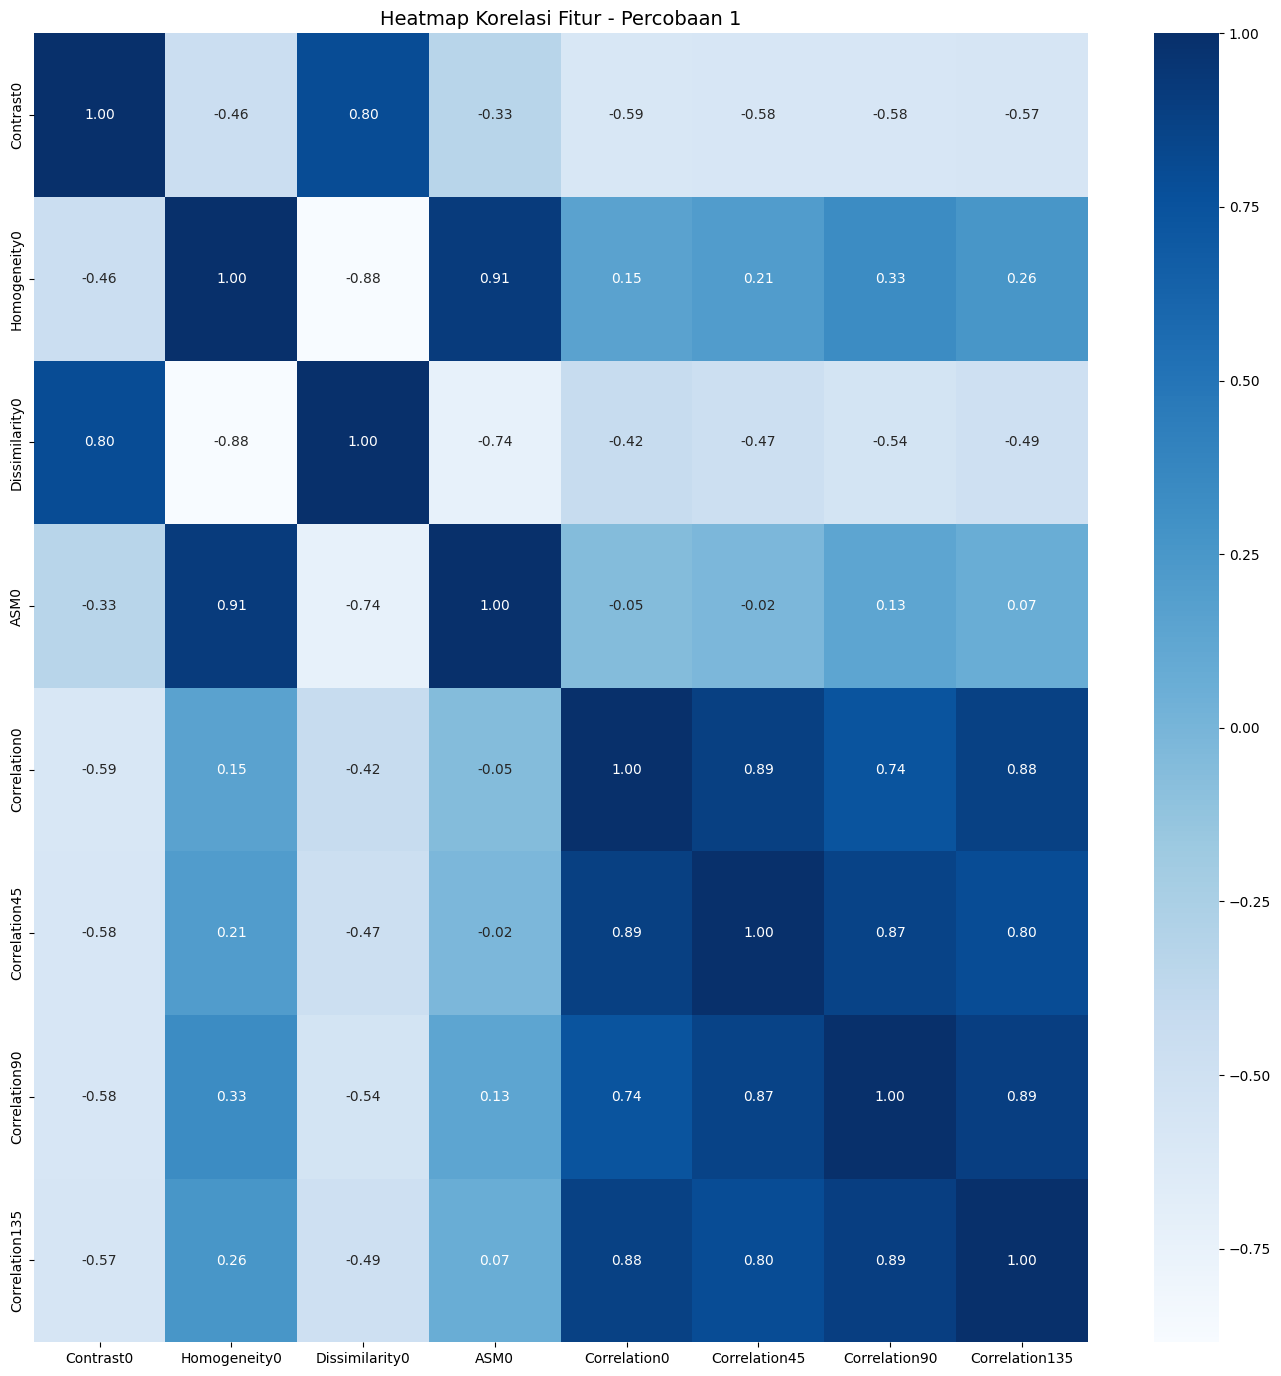

In [157]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : 28")
print(f"Fitur setelah seleksi : {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 1', fontsize=14)
plt.show()

## Membagi data menjadi set training dan testing dengan rasio 80:20
Pada code terdapat:

- train_test_split dengan test_size=0.2 untuk membagi 80% data sebagai data latih dan 20% sebagai data uji
- random_state=42 untuk memastikan pembagian data yang konsisten setiap kali dijalankan
- print untuk menampilkan dimensi X_train dan X_test sebagai verifikasi jumlah sampel dan fitur

In [158]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(160, 8)
(40, 8)


### Melakukan normalisasi fitur menggunakan metode Z-score berdasarkan statistik data training
Pada code terdapat:

- X_train.mean() dan X_train.std() untuk menghitung rata-rata dan standar deviasi dari data training
- Normalisasi diterapkan ke X_train dan X_test menggunakan rumus (X - mean) / std; penting bahwa statistik yang digunakan hanya dari data training untuk menghindari data leakage

In [159]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

## Modeling

### Mendefinisikan fungsi untuk mencetak laporan klasifikasi dan confusion matrix, lalu mendefinisikan tiga model klasifikasi
Pada code terdapat:

- Fungsi generateClassificationReport yang mencetak classification_report, confusion_matrix, dan accuracy_score untuk evaluasi menyeluruh
- RandomForestClassifier dengan 5 pohon keputusan (n_estimators=5) dan random_state=42
- SVC dengan kernel RBF dan random_state=42
- KNeighborsClassifier dengan 5 tetangga terdekat (n_neighbors=5)

In [160]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

### Melatih model Random Forest lalu mengevaluasinya pada data training dan data testing
Pada code terdapat:

- rf.fit(X_train, y_train) untuk melatih model Random Forest menggunakan data training
- rf.predict dipanggil dua kali: pertama pada X_train untuk melihat performa training, kedua pada X_test untuk melihat performa generalisasi model
- generateClassificationReport untuk menampilkan precision, recall, F1-score, confusion matrix, dan akurasi untuk masing-masing set data

In [161]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.96      1.00      0.98        81
     daun_sehat_100       1.00      0.96      0.98        79

           accuracy                           0.98       160
          macro avg       0.98      0.98      0.98       160
       weighted avg       0.98      0.98      0.98       160

[[81  0]
 [ 3 76]]
Accuracy: 0.98125

------Testing Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.95      1.00      0.97        19
     daun_sehat_100       1.00      0.95      0.98        21

           accuracy                           0.97        40
          macro avg       0.97      0.98      0.97        40
       weighted avg       0.98      0.97      0.98        40

[[19  0]
 [ 1 20]]
Accuracy: 0.975


### Melatih model SVM lalu mengevaluasinya pada data training dan data testing
Pada code terdapat:

- svm.fit(X_train, y_train) untuk melatih model SVM dengan kernel RBF
- svm.predict dipanggil pada X_train dan X_test untuk menghasilkan prediksi pada masing-masing set
- generateClassificationReport untuk menampilkan laporan evaluasi lengkap pada kedua set data

In [162]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.90      0.96      0.93        81
     daun_sehat_100       0.96      0.89      0.92        79

           accuracy                           0.93       160
          macro avg       0.93      0.92      0.92       160
       weighted avg       0.93      0.93      0.92       160

[[78  3]
 [ 9 70]]
Accuracy: 0.925

------Testing Set------


                     precision    recall  f1-score   support

Grape_black_rot_100       0.90      0.95      0.92        19
     daun_sehat_100       0.95      0.90      0.93        21

           accuracy                           0.93        40
          macro avg       0.93      0.93      0.92        40
       weighted avg       0.93      0.93      0.93        40

[[18  1]
 [ 2 19]]
Accuracy: 0.925


### Melatih model KNN lalu mengevaluasinya pada data training dan data testing
Pada code terdapat:

- knn.fit(X_train, y_train) untuk melatih model KNN menggunakan 5 tetangga terdekat
- knn.predict dipanggil pada X_train dan X_test untuk prediksi pada masing-masing set
- generateClassificationReport untuk menampilkan laporan evaluasi lengkap pada kedua set data

In [163]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)



------Training Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.89      0.91      0.90        81
     daun_sehat_100       0.91      0.89      0.90        79

           accuracy                           0.90       160
          macro avg       0.90      0.90      0.90       160
       weighted avg       0.90      0.90      0.90       160

[[74  7]
 [ 9 70]]
Accuracy: 0.9

------Testing Set------
                     precision    recall  f1-score   support

Grape_black_rot_100       0.90      0.95      0.92        19
     daun_sehat_100       0.95      0.90      0.93        21

           accuracy                           0.93        40
          macro avg       0.93      0.93      0.92        40
       weighted avg       0.93      0.93      0.93        40

[[18  1]
 [ 2 19]]
Accuracy: 0.925


## Menampilkan confusion matrix untuk ketiga model secara visual menggunakan heatmap berwarna biru
Pada code terdapat:

- Fungsi plot_confusion_matrix yang menerima label asli, prediksi, dan judul; menghitung confusion matrix menggunakan confusion_matrix lalu menampilkannya menggunakan ConfusionMatrixDisplay
- Fungsi dipanggil tiga kali untuk Random Forest, SVM, dan KNN dengan prediksi dari data testing
- plt.cm.Blues digunakan sebagai colormap agar tampilan konsisten dan mudah dibaca

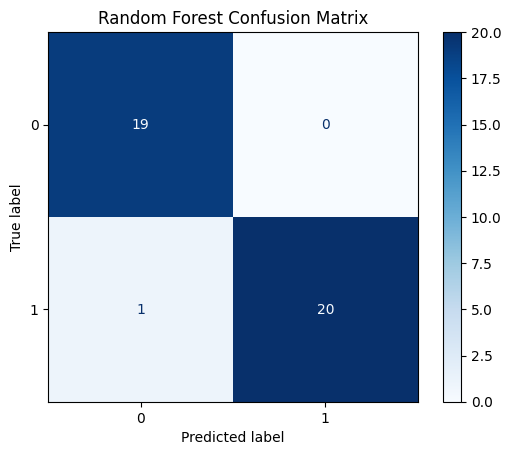

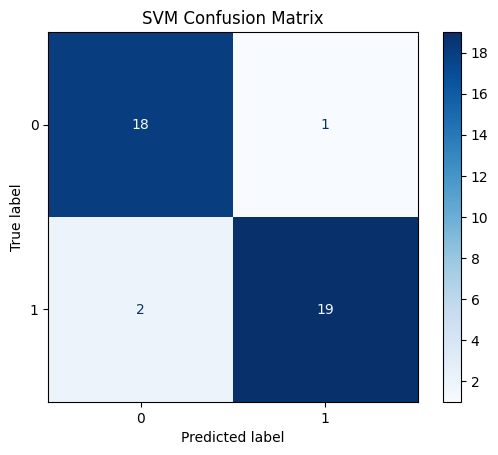

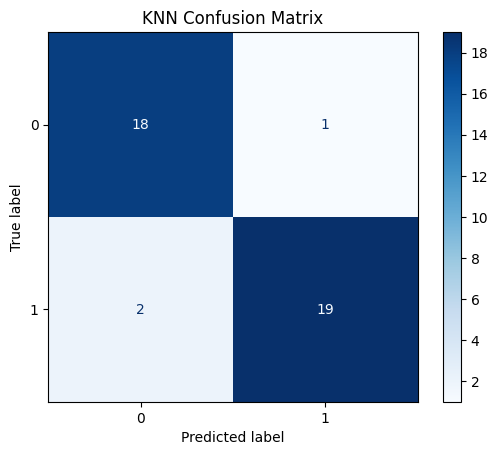

In [164]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

### Menyusun perbandingan performa ketiga model ke dalam DataFrame lalu menyimpannya ke file CSV dan menampilkan hasilnya
Pada code terdapat:

- Dictionary hasil_klasifikasi yang menghitung Accuracy_Train, Accuracy_Test, Precision, Recall, dan F1_Score untuk masing-masing model menggunakan fungsi evaluasi dari sklearn
- average='weighted' pada precision, recall, dan F1 score untuk memperhitungkan ketidakseimbangan jumlah sampel antar kelas
- pd.DataFrame untuk mengonversi dictionary menjadi tabel perbandingan
- df_hasil.to_csv untuk menyimpan hasil ke hasil_klasifikasi1.csv di folder klasifikasi

In [165]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)
df_hasil.to_csv('./klasifikasi/hasil_klasifikasi1.csv', index=False)
df_hasil

,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,0.98125,0.975,0.97625,0.975,0.975016
1,SVM,0.92500,0.925,0.92625,0.925,0.925047
2,KNN,0.90000,0.925,0.92625,0.925,0.925047
